In [1]:
# моделирование траекторий
# фрактального броуновского движения
# в неограниченной области

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение функций fft, fftfreq
from scipy.fft import fft

# подключение библиотеки random
import random

# инициализация генератора
# случайных чисел
random.seed()

In [2]:
# Ячейка № 2
def Mid_FBM(H, Sigma, Ratio, Level):
    # вычисление значения
    # корректирующего коэффициента
    Ro = np.sqrt(1 - 2 ** (2 * H - 2))

    # вычисление числа шагов
    # броуновской частицы
    N = 2**Level

    # инициализация массива X
    X = np.zeros(N + 1)

    # вычисление координаты
    # броуновской частицы
    # на ее последнем шаге
    X[N] = Ratio ** (Level + 1) * Ro * Sigma * random.gauss(0, Sigma)

    # реализация вычислений
    # координат траектории
    # броуновской частицы
    # в соответствие с алгоритмом I
    for i in range(1, Level + 1):
        if i == 1:
            Number = np.array([N / 2**i, N / 2 ** (i - 1), 0], dtype=int)

            X[Number[0]] = 0.5 * (X[Number[2]] + X[Number[1]]) + Ratio ** (
                i * H
            ) * Ro * Sigma * random.gauss(0, Sigma)

        if i == 2:
            for m in range(1, i + 1):
                Number = np.array(
                    [
                        (2 * m - 1) * N / 2**i,
                        m * N / 2 ** (i - 1),
                        (m - 1) * N / 2 ** (i - 1),
                    ],
                    dtype=int,
                )

                X[Number[0]] = 0.5 * (X[Number[1]] + X[Number[2]]) + Ratio ** (
                    i * H
                ) * Ro * Sigma * random.gauss(0, Sigma)
        if i > 2:
            for m in range(1, 2 ** (i - 1) + 1):
                Number = np.array(
                    [
                        (2 * m - 1) * N / 2**i,
                        m * N / 2 ** (i - 1),
                        (m - 1) * N / 2 ** (i - 1),
                    ],
                    dtype=int,
                )

                X[Number[0]] = 0.5 * (X[Number[1]] + X[Number[2]]) + Ratio ** (
                    i * H
                ) * Ro * Sigma * random.gauss(0, Sigma)

    return X


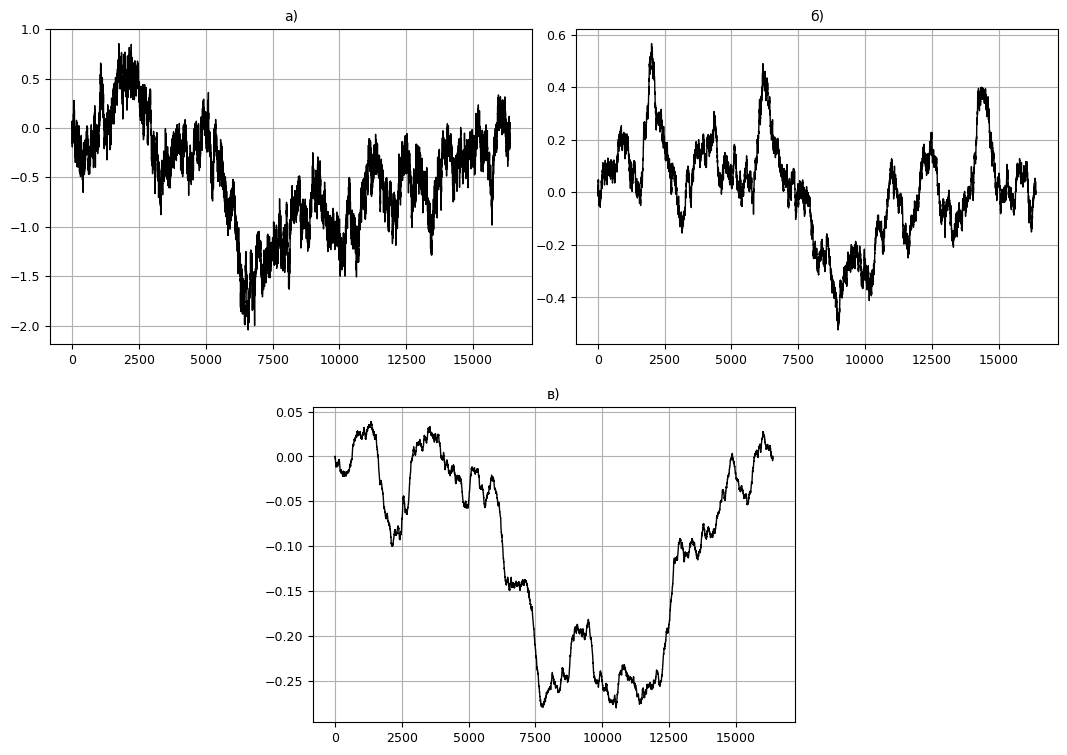

In [3]:
# Ячейка № 3

# задание значения числа n
# (в описании алгоритма)
Level = 14

# задание значения
# масштабирующего множителя
Sigma = 1

# задание значения
# коэффициента скэйлинга
Ratio = 0.5
# расчет траекторий
# броуновской частицы
# для случаев H = 0.3, 0.5, 0,8

H1 = 0.3
X1 = Mid_FBM(H1, Sigma, Ratio, Level)

H2 = 0.5
X2 = Mid_FBM(H2, Sigma, Ratio, Level)

H3 = 0.8
X3 = Mid_FBM(H3, Sigma, Ratio, Level)

# визуализация траекторий
# броуновской частицы
fig = plt.figure(figsize=(13, 9))

ax0 = plt.subplot2grid((2, 4), (0, 0), colspan=2)
ax1 = plt.subplot2grid((2, 4), (0, 2), colspan=2)
ax2 = plt.subplot2grid((2, 4), (1, 1), colspan=2)

ax0.plot(X1, "-k", lw=1)
ax0.grid(True)
ax0.set_title("а)", fontsize=10)
ax0.tick_params(axis="both", which="major", labelsize=9)
ax1.plot(X2, "-k", lw=1)
ax1.grid(True)
ax1.tick_params(axis="both", which="major", labelsize=9)
ax1.set_title("б)", fontsize=10)
ax2.plot(X3, "-k", lw=1)
ax2.grid(True)
ax2.tick_params(axis="both", which="major", labelsize=9)
ax2.set_title("в)", fontsize=10)

plt.show()

In [4]:
# Ячейка № 3

# задание рекурсивной функции,
# возвращающий значения координат
# траектории броуновской
# частицы, совершающей блуждания
# в неограниченной области рассеяния
def Divide2Part_FBM(X, H, Ratio, Sigma, Std, I0, I2, Level, Max_Level):
    # входные переменные:
    # X - массив, содержащий координаты
    #     траектории броуновской частицы
    #     возвращенных на предыдущем уровне рекурсии
    # H - показатель Херста
    # Ratio - коэффициент скэйлинга
    # Sigma - масштабирующий множитель
    # I0, I2 - номера крайне левой и крайне
    #          правой точек отрезка на предыдущем
    #          уровне рекурсии, в середине которого
    #          вычисляется значение траектории
    #          броуновской частицы
    # Level - номер предыдущего уровня рекурсии
    # MaxLevel - соответствует числу n в описании
    #            алгоритма № II

    # вычисление координаты
    # середины отрезка [I0, I2]
    I1 = (I0 + I2) // 2

    # вычисление значения
    # I1-ой координаты траектории
    # броуновской частицы
    X[I1] = 0.5 * (X[I0] + X[I2]) + Std * Sigma * random.gauss(0, 1)

    # рекурсия
    if Level <= Max_Level - 1:
        Stdmid = Std * Ratio

        # вычисление координаты
        # траектории броуновской частицы
        # в середине отрезка [I0, I1]
        X = Divide2Part_FBM(X, H, Ratio, Sigma, Stdmid, I0, I1, Level + 1, Max_Level)

        # вычисление координаты
        # траектории броуновской частицы
        # в середине отрезка [I1, I2]
        X = Divide2Part_FBM(X, H, Ratio, Sigma, Stdmid, I1, I2, Level + 1, Max_Level)

    return X

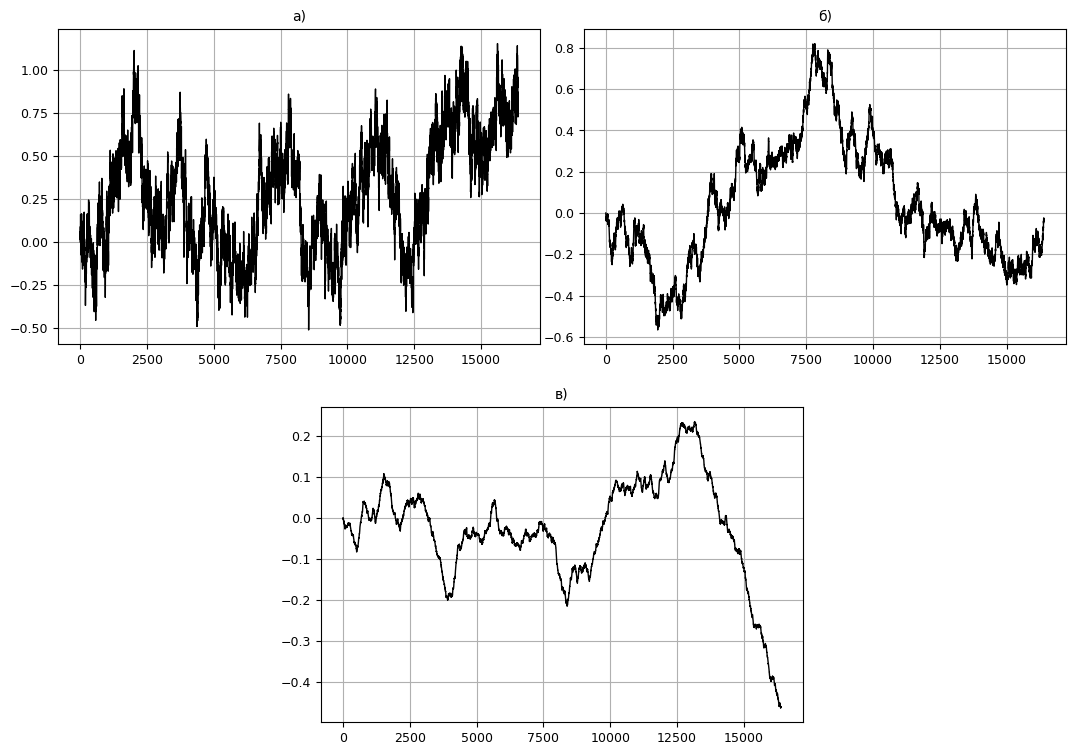

In [5]:
# Ячейка № 4

# задание значений показателя Херста
H1 = 0.3
H2 = 0.5
H3 = 0.8

# задание значений
# коэффициента скэйлинга
Ratio_1 = 1 / 2**H1
Ratio_2 = 1 / 2**H2
Ratio_3 = 1 / 2**H3

# задание значения числа n
# (в описании алгоритма)
Max_Level = 14

# задание значения
# масштабирующего множителя
Sigma = 1

Std = Sigma * Ratio

# вычисление числа шагов
# броуновской частицы
N = 2**Max_Level

# инициализация счетчика уровней рекурсии
Level = 1

# инициализация массивов,
# используемых для хранения
# координат траектории
# броуновской частицы
X1 = np.zeros(N + 1)
X2 = np.zeros(N + 1)
X3 = np.zeros(N + 1)

# вычисление координат
# броуновской частицы
# на ее последнем шаге

X1[N] = 0.5**H1 * Sigma * random.gauss(0, 1)

X2[N] = 0.5**H2 * Sigma * random.gauss(0, 1)

X3[N] = 0.5**H3 * Sigma * random.gauss(0, 1)

I0 = 0
I2 = N

# вычисление координат
# траекторий броуновской частицы
X1 = Divide2Part_FBM(X1, H1, Ratio_1, Sigma, Std, I0, I2, Level, Max_Level)

X2 = Divide2Part_FBM(X2, H2, Ratio_2, Sigma, Std, I0, I2, Level, Max_Level)

X3 = Divide2Part_FBM(X3, H3, Ratio_3, Sigma, Std, I0, I2, Level, Max_Level)

# визуализация траекторий
# броуновской частицы
fig = plt.figure(figsize=(13, 9))

ax0 = plt.subplot2grid((2, 4), (0, 0), colspan=2)
ax1 = plt.subplot2grid((2, 4), (0, 2), colspan=2)
ax2 = plt.subplot2grid((2, 4), (1, 1), colspan=2)

ax0.plot(X1, "-k", lw=1)
ax0.grid(True)
ax0.set_title("а)", fontsize=10)
ax0.tick_params(axis="both", which="major", labelsize=9)
ax1.plot(X2, "-k", lw=1)
ax1.grid(True)
ax1.tick_params(axis="both", which="major", labelsize=9)
ax1.set_title("б)", fontsize=10)
ax2.plot(X3, "-k", lw=1)
ax2.grid(True)
ax2.tick_params(axis="both", which="major", labelsize=9)
ax2.set_title("в)", fontsize=10)

plt.show()

In [6]:
# Ячейка № 5

# задание функции,
# возвращающей координаты
# траектории фрактального
# броуновского движения,
# вычисленные на основе Фурье-фильтрации


def FBM_FF(H, Level):
    # входные переменные:
    # H - показатель Херста
    # Level - показатель степени числа 2

    # вычисление длины траектории
    N = 2**Level

    # иницализация комплекснозначного массива
    X = np.zeros(N) * 1j

    # вычисление координаты
    # начальной точки траектории
    X[0] = random.gauss(0, 1)

    # вычисление координат
    # фрактальной траектории
    # на основе Фурье-фильтрации
    for i in range(1, N // 2 - 1):
        Tmp = random.gauss(0, 1) * np.exp(2 * np.pi * 1j * random.uniform(0, 1))
        X[i] = Tmp / i ** (H + 0.5)
    for i in (N // 2 + 1, N - 1):
        X[i] = np.conj(X[N - i])
    X = fft(X)

    return np.real(X - X[0])

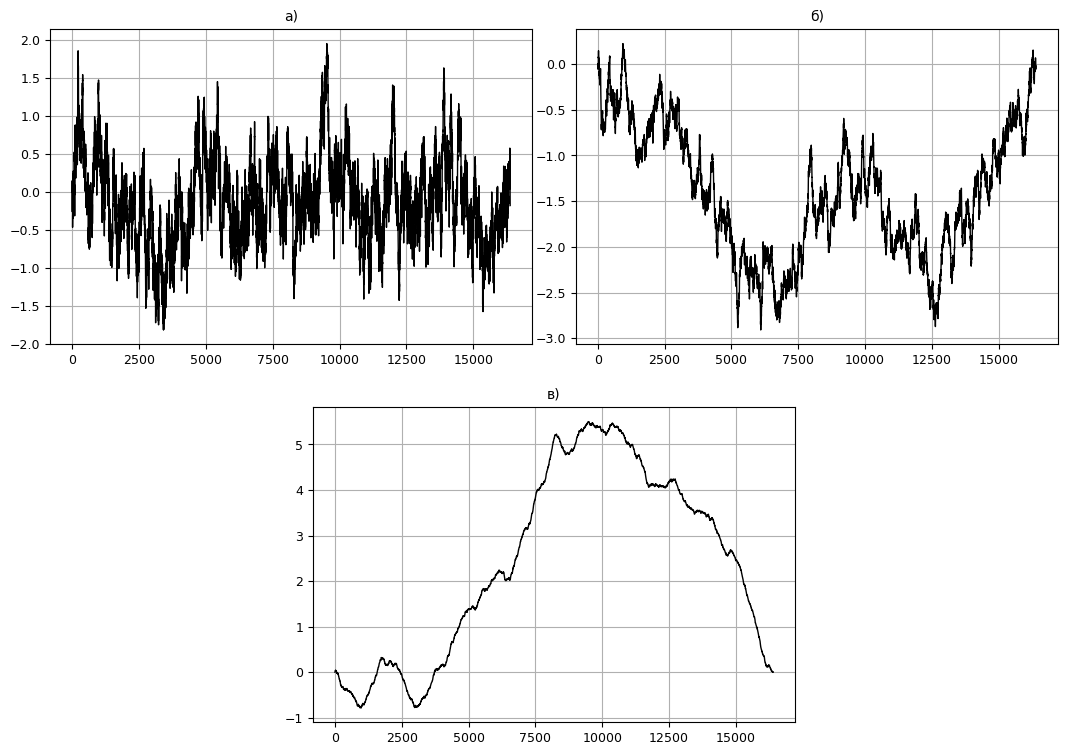

In [7]:
# Ячейка № 6

# задание значений показателя Херста
H1 = 0.3
H2 = 0.5
H3 = 0.8

# задание значения числа n
# (в описании алгоритма)
Max_Level = 14

X1 = FBM_FF(H1, Max_Level)
X2 = FBM_FF(H2, Max_Level)
X3 = FBM_FF(H3, Max_Level)

# визуализация траекторий
# броуновской частицы
fig = plt.figure(figsize=(13, 9))


ax0 = plt.subplot2grid((2, 4), (0, 0), colspan=2)
ax1 = plt.subplot2grid((2, 4), (0, 2), colspan=2)
ax2 = plt.subplot2grid((2, 4), (1, 1), colspan=2)

ax0.plot(X1, "-k", lw=1)
ax0.grid(True)
ax0.set_title("а)", fontsize=10)
ax0.tick_params(axis="both", which="major", labelsize=9)
ax1.plot(X2, "-k", lw=1)
ax1.grid(True)
ax1.tick_params(axis="both", which="major", labelsize=9)
ax1.set_title("б)", fontsize=10)
ax2.plot(X3, "-k", lw=1)
ax2.grid(True)
ax2.tick_params(axis="both", which="major", labelsize=9)
ax2.set_title("в)", fontsize=10)

plt.show()